<a href="https://colab.research.google.com/github/ENRIQUESPECTER/Mineria-de-Datos/blob/main/CLUSTER_AGLOMERATIVO/CLUSTER_AGLOMERATIVO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio 1 — Agrupación básica**
**Objetivo: Entender cómo el algoritmo une puntos cercanos.**


In [536]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

In [537]:
X = np.array([
    [1, 1],   # A
    [2, 1],   # B
    [5, 5],   # C
    [6, 5],   # D
    [10,10],  # E
    [11,10]   # F
])

puntos = ["A","B","C","D","E","F"]

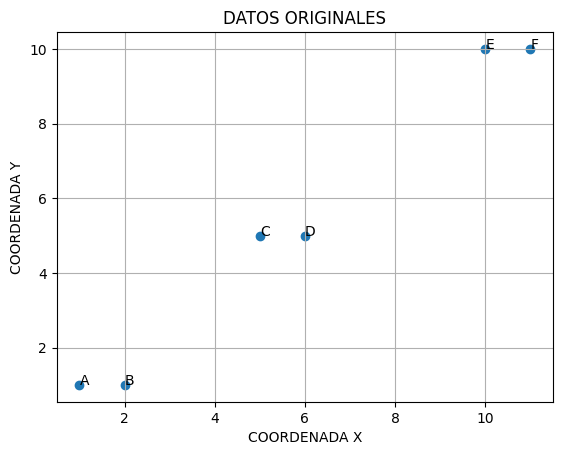

In [538]:
# Graficar los datos antes del clustering.
plt.scatter(X[:,0], X[:,1]) #TODAS LAS FILAS DE LA COLUMNA X Y LA COLUMNA Y

for punto, (x,y) in zip(puntos, X): #combina las listas en una sola
  plt.annotate(punto, (x,y))

plt.title("DATOS ORIGINALES")
plt.xlabel("COORDENADA X")
plt.ylabel("COORDENADA Y")
plt.grid(True)
plt.show()

In [539]:
# Aplicar clustering jerárquico aglomerativo con linkage='ward'
Z = linkage(
    X,
    method='ward',
    metric='euclidean'
)
print("MATRIZ DE LINKAGE\n")
print(Z)

MATRIZ DE LINKAGE

[[ 0.          1.          1.          2.        ]
 [ 2.          3.          1.          2.        ]
 [ 4.          5.          1.          2.        ]
 [ 6.          7.          8.          4.        ]
 [ 8.          9.         16.16580754  6.        ]]


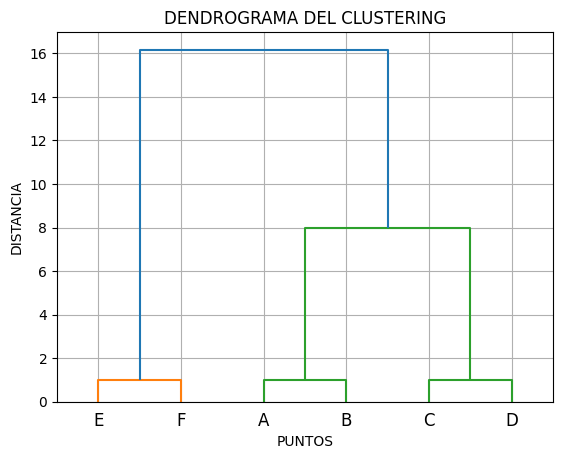

In [540]:
# Generar el dendrograma.
dendrogram(Z,labels=puntos)

plt.title("DENDROGRAMA DEL CLUSTERING")
plt.xlabel("PUNTOS")
plt.ylabel("DISTANCIA")
plt.grid(True)
plt.show()

In [541]:
# MODELO AGLOMERATIVO
modelo = AgglomerativeClustering(n_clusters=3, linkage='ward')
etiquetas = modelo.fit_predict(X)

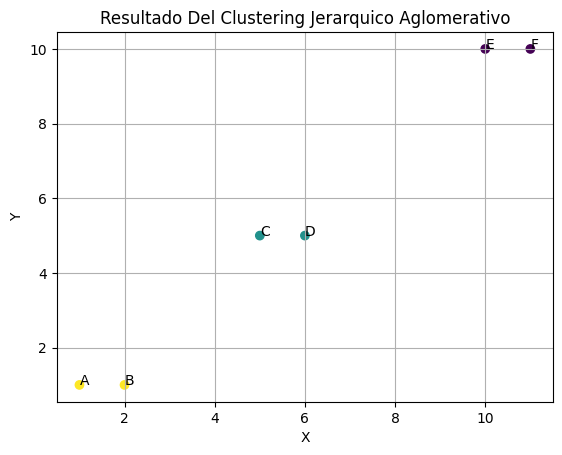

In [542]:
# GRAFICA DE RESULTADO FINAL
plt.scatter(X[:,0], X[:,1], c=etiquetas)

# SE AGREGAN LAS LETRAS EN CADA PUNTO
for punto, (x,y) in zip(puntos,X):
  plt.annotate(punto,(x,y))

plt.title("Resultado Del Clustering Jerarquico Aglomerativo")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

**¿Qué puntos se unen primero y por qué?**
E y F porque son los más cercanos.

**¿Qué sucede al cortar el dendrograma en una altura pequeña?**
Se obtienen más clusters que si se cortará en una parte alta.

**¿Qué cambia al cortar el árbol más arriba?**
Los puntos se unen más, reduciendo los clusters.

**¿Qué significa la altura donde se unen dos ramas?**
Significa una fusión de clusters o grupos.

**¿Cuántos clusters aparecen al cortar aproximadamente en distancia 8?**
Aparecen solo 2 clusters, porque quedan E Y F como un grupo y la fusion de A,B,C Y D

# **Ejercicio 2 — Segmentación de clientes**
**Contexto: Una tienda quiere segmentar clientes según edad y gasto mensual.**

In [543]:
X = np.array([
    [20, 100],
    [22, 120],
    [23, 140],
    [45, 700],
    [46, 750],
    [48, 720],
    [60, 1500],
    [62, 1600]
])
clientes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

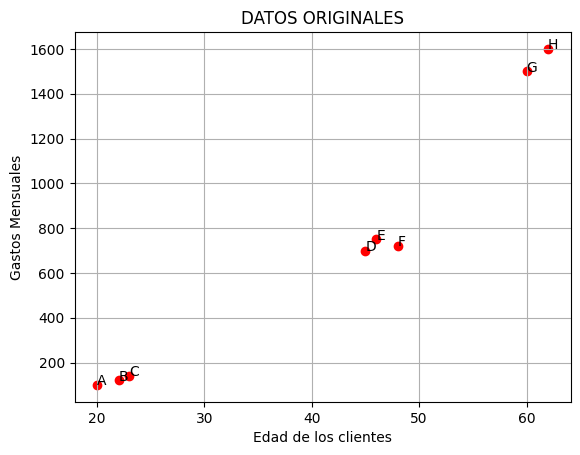

In [544]:
# Graficar los datos.
plt.scatter(X[:,0], X[:,1], color='red')

for cliente, (x,y) in zip(clientes, X): #combina las listas en una sola
  plt.annotate(cliente, (x,y))

plt.title("DATOS ORIGINALES")
plt.xlabel("Edad de los clientes")
plt.ylabel("Gastos Mensuales")
plt.grid(True)
plt.show()

In [545]:
# Aplicar clustering jerárquico aglomerativo con linkage='ward'
Z = linkage(
    X,
    method='ward',
    metric='euclidean'
)
print("MATRIZ DE LINKAGE\n")
print(Z)

MATRIZ DE LINKAGE

[[1.00000000e+00 2.00000000e+00 2.00249844e+01 2.00000000e+00]
 [3.00000000e+00 5.00000000e+00 2.02237484e+01 2.00000000e+00]
 [0.00000000e+00 8.00000000e+00 3.47610894e+01 3.00000000e+00]
 [4.00000000e+00 9.00000000e+00 4.61916298e+01 3.00000000e+00]
 [6.00000000e+00 7.00000000e+00 1.00019998e+02 2.00000000e+00]
 [1.00000000e+01 1.10000000e+01 1.04587698e+03 6.00000000e+00]
 [1.20000000e+01 1.30000000e+01 1.95489011e+03 8.00000000e+00]]


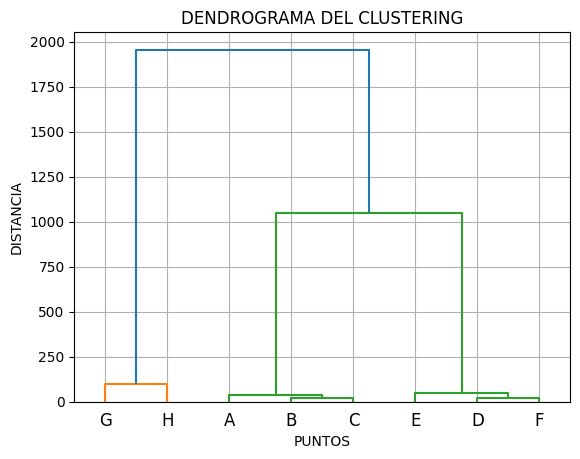

In [546]:
# Generar dendrograma.
dendrogram(Z, labels=clientes)

plt.title("DENDROGRAMA DEL CLUSTERING")
plt.xlabel("PUNTOS")
plt.ylabel("DISTANCIA")
plt.grid(True)
plt.show()

In [547]:
#Probar: n_clusters=2 n_clusters=3 y comparar
modelo = AgglomerativeClustering(n_clusters=2, linkage='ward')
primermodelo = modelo.fit_predict(X)

modelo_alterno = AgglomerativeClustering(n_clusters=3, linkage='ward')
segundomodelo = modelo_alterno.fit_predict(X)

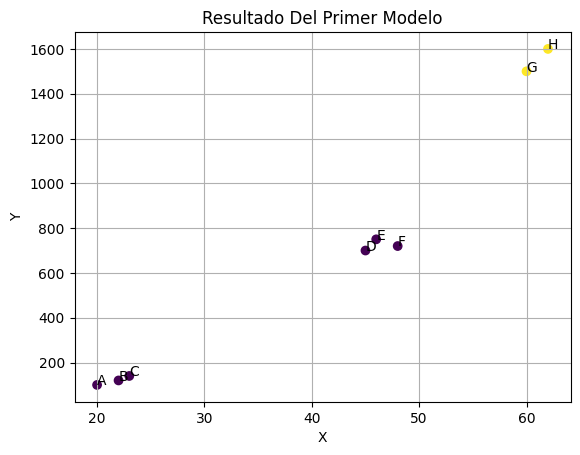

In [548]:
plt.scatter(X[:,0], X[:,1], c=primermodelo)

for cliente, (x,y) in zip(clientes, X):
  plt.annotate(cliente, (x,y))

plt.title("Resultado Del Primer Modelo")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

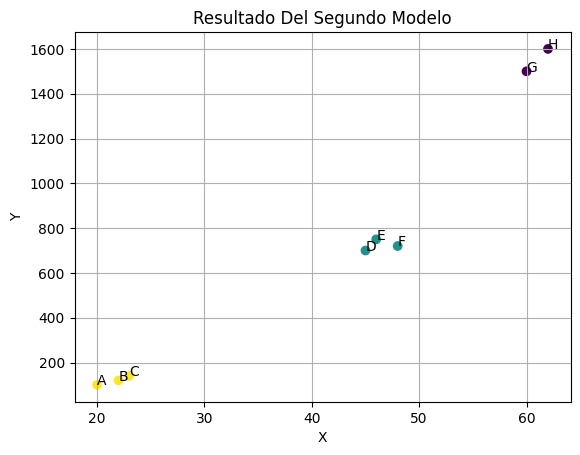

In [549]:
plt.scatter(X[:,0], X[:,1], c=segundomodelo)

for cliente, (x,y) in zip(clientes, X):
  plt.annotate(cliente, (x,y))

plt.title("Resultado Del Segundo Modelo")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

# **Preguntas de interpretación**
**¿Qué clientes parecen más similares?**
Los clientes A, B Y C.

**¿Qué grupos naturales identifica el algoritmo?**
Los grupos (G,H), (A,B,C) Y (E,D,F).

**¿Qué representa cada cluster desde el punto de vista comercial?**
Muestra los clientes recurrentes y que más compran o gastan mensualmente.

**¿Cuál sería una estrategia de marketing para cada grupo?**
Bonificar mas a los clientes.

**¿Por qué el algoritmo agrupa ciertos clientes?**
Debido a su cercania y similitud.

# **Ejercicio 3 — Rendimiento académico**
**Contexto: Una escuela quiere identificar tipos de estudiantes según desempeño. (Promedio , asistencia)**

In [550]:
X = np.array([
    [95, 98],  # Alumno A
    [92, 94],  # Alumno B
    [88, 90],  # Alumno C
    [65, 70],  # Alumno D
    [60, 68],  # Alumno E
    [58, 62],  # Alumno F
    [30, 40],  # Alumno G
    [35, 38]   # Alumno H
])
alumnos = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

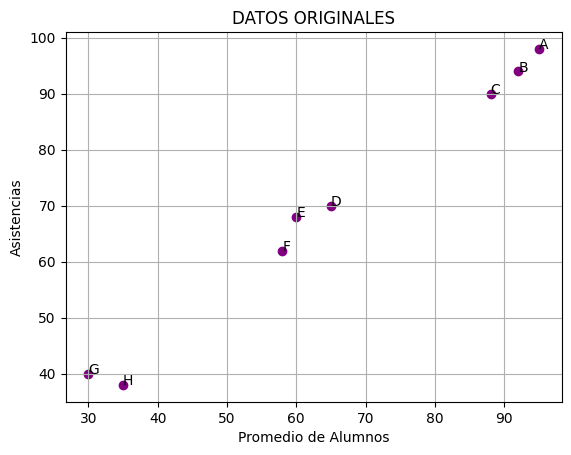

In [551]:
#Aplicar clustering jerárquico.
plt.scatter(X[:,0], X[:,1], color='purple')

for alumno, (x,y) in zip(alumnos,X):
  plt.annotate(alumno,(x,y))

plt.title("DATOS ORIGINALES")
plt.xlabel("Promedio de Alumnos")
plt.ylabel("Asistencias")
plt.grid(True)
plt.show()

In [552]:
Z = linkage(
    X,
    method='ward',
    metric='euclidean'
)
print(Z)

[[  0.           1.           5.           2.        ]
 [  3.           4.           5.38516481   2.        ]
 [  6.           7.           5.38516481   2.        ]
 [  2.           8.           9.39858145   3.        ]
 [  5.           9.           9.60902354   3.        ]
 [ 10.          12.          61.53427229   5.        ]
 [ 11.          13.         110.29785432   8.        ]]


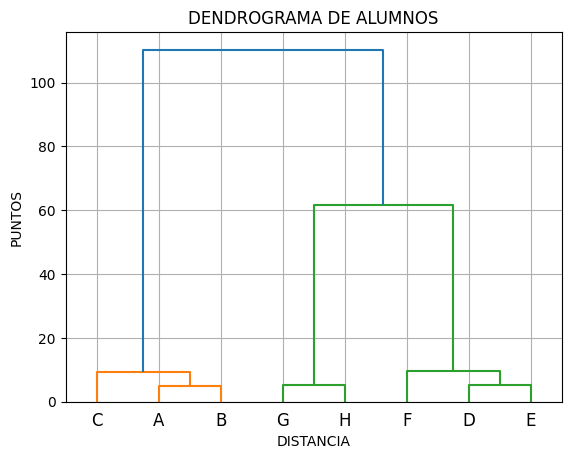

In [553]:
# OBSERVAR EL DENDROGRAMA
dendrogram(Z, labels=alumnos)

plt.title("DENDROGRAMA DE ALUMNOS")
plt.xlabel("DISTANCIA")
plt.ylabel("PUNTOS")
plt.grid(True)
plt.show()

In [554]:
# Formar: 2 clusters 3 clusters y Comparar interpretaciones.
modelo_uno = AgglomerativeClustering(n_clusters=2, linkage='ward')
firstmodel = modelo_uno.fit_predict(X)

modelo_dos = AgglomerativeClustering(n_clusters=3, linkage='ward')
secondmodel = modelo_dos.fit_predict(X)

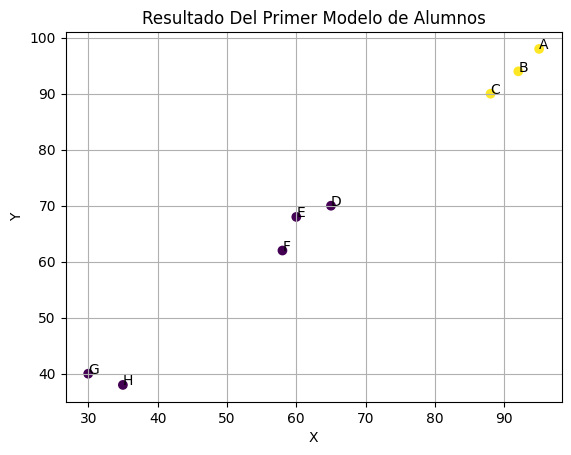

In [555]:
plt.scatter(X[:,0], X[:,1], c=firstmodel)

for alumno, (x,y) in zip(alumnos,X):
  plt.annotate(alumno,(x,y))

plt.title("Resultado Del Primer Modelo de Alumnos")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

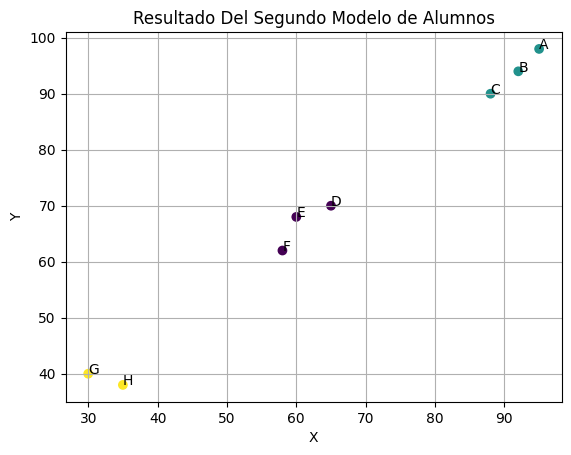

In [556]:
plt.scatter(X[:,0], X[:,1], c=secondmodel)

for alumno, (x,y) in zip(alumnos,X):
  plt.annotate(alumno,(x,y))

plt.title("Resultado Del Segundo Modelo de Alumnos")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

**¿Qué alumnos se parecen más?**
Los 3 grupos entre sus miembros tienen muchos parecidos.

**¿Qué perfiles de estudiantes aparecen?**
Perfiles de Excelencia Acádemica regulares y los irregulares.

**¿Qué decisión institucional podría tomarse con esta información?**
Hace falta una mejora en los alumnos, debido a que se inclina más a promedios y asistencias bajos.

**¿Qué ocurre cuando el número de clusters cambia?**
Simplemente se fusionan con otros clusters.

**¿Qué grupo requeriría más intervención académica?**
El grupo (G,H)